# <center><span style='color:red'><b>DEFINING REGIMES</b></span></center>

## Imports
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [3]:
import xarray as xr
import numpy as np
from scipy.ndimage import uniform_filter1d
from eofs.xarray import Eof
import pandas as pd       
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [4]:
# Open with xarray
#data = xr.open_zarr('/gws/nopw/j04/coast_hack/datasets/GLORYS/GLOBAL_MULTIYEAR_PHY_001_030/Subset_NorthAtlantic_regrid1x1/cmems_mod_glo_phy_my_0.083deg_P1D-m_mlotst_100.00W-20.00E_0.00N-80.00N_1993-01-01-2021-06-30.zarr').load()
data = xr.open_zarr('/gws/ssde/j25a/co2clim/datasets/GLORYS/GLOBAL_MULTIYEAR_PHY_001_030/Subset_NorthAtlantic_regrid1x1/cmems_mod_glo_phy_my_0.083deg_P1D-m_mlotst_100.00W-20.00E_0.00N-80.00N_1993-01-01-2021-06-30.zarr').load()

# Print a summary of dataset
print(data)

<xarray.Dataset> Size: 408MB
Dimensions:    (latitude: 81, longitude: 121, time: 10408)
Coordinates:
  * latitude   (latitude) float64 648B 0.0 1.0 2.0 3.0 ... 77.0 78.0 79.0 80.0
  * longitude  (longitude) float64 968B -100.0 -99.0 -98.0 ... 18.0 19.0 20.0
  * time       (time) datetime64[ns] 83kB 1993-01-01 1993-01-02 ... 2021-06-30
Data variables:
    mlotst     (time, latitude, longitude) float32 408MB 10.53 10.53 ... nan nan


## Clean and process data
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [5]:
# ----------------------------------
# Ensure required dimensions
# ----------------------------------
required_dims = {"time", "latitude", "longitude"}
if not required_dims.issubset(data.dims):
    raise ValueError(f"DataArray must have dimensions {required_dims}, "f"found {data.dims}")

# ----------------------------------
# Enforce consistent dimension order
# ----------------------------------
data = data.transpose("time", "latitude", "longitude")

# ----------------------------------
# Crop spatial domain
# ----------------------------------
data = data.sel(latitude=slice(26, 65), longitude=slice(-80, -1))

# ----------------------------------
# Select only full years (1993–2020)
# ----------------------------------
data = data.sel(time=slice("1993-01-01", "2020-12-31"))

# ----------------------------------
# Resample to daily frequency
# ----------------------------------
data = data.resample(time="1D").asfreq()


<h2 style="color:red;">Drop first five years of the dataset</h2>

In [6]:
#data = data.sel(time=slice("1998-01-01", None))

## Compute climatology and anomalies
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [7]:
# ----------------------------------
# Parameters for climatology/anomalies
# ----------------------------------
if isinstance(data, xr.Dataset):
    data = data["mlotst"]

# ----------------------------------
# Deal with leap years (remove Feb 29)
# ----------------------------------
# Remove Feb 29
is_feb29 = (data.time.dt.month == 2) & (data.time.dt.day == 29)
data = data.sel(time=~is_feb29)

# Compute day365 index using pandas
time_pd = data.time.to_index()
year = time_pd.year
day_index = pd.Series(np.arange(len(time_pd)), index=time_pd).groupby(year).cumcount().values
data = data.assign_coords(day365=("time", day_index))

# ----------------------------------
# Parameters for climatology/anomalies
# ----------------------------------
climo_smooth_days = 1   # Number of days for smoothing the daily climatology
# Set >1 if you want to smooth climatology in time (ERA often used 1 or 5)

# ----------------------------------
# Compute daily climatology
# ----------------------------------
climatology = data.groupby("day365").mean("time", skipna=True)

# ----------------------------------
# Optional smoothing
# ----------------------------------
if climo_smooth_days > 1:
    climatology = xr.apply_ufunc(uniform_filter1d, climatology, kwargs=dict(size=climo_smooth_days, axis=0, mode="wrap"), input_core_dims=[["day365"]], output_core_dims=[["day365"]],)

# ----------------------------------
# Compute anomalies
# ----------------------------------
anomalies = data.groupby("day365") - climatology


# Create a "fake" day-of-year coordinate as strings
day_labels = pd.date_range("2001-01-01", "2001-12-31", freq="D").strftime("%m-%d")
climatology = climatology.assign_coords(day365=("day365", day_labels))

# ----------------------------------
# Quick sanity checks
# ----------------------------------
assert climatology.sizes["day365"] == 365
assert anomalies.sizes["time"] == data.sizes["time"]

#print("Climatology shape:", climatology.shape)
#print("Anomalies shape:", anomalies.shape)
#print("Example climatology values (day 1, first lat/lon):", climatology.isel(day365=0, latitude=0, longitude=0).values)
#print("Example anomaly values (first day, first lat/lon):", anomalies.isel(time=0, latitude=0, longitude=0).values)
#print("First 5 day labels:", climatology.day365.values[:5])
#print("Last 5 day labels:", climatology.day365.values[-5:])

# ----------------------------------
# Output
# ----------------------------------
# climatology(dayofyear, latitude, longitude)
# anomalies(time, latitude, longitude)

## Seasonal subsetting
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [8]:
# ----------------------------------
# Keep full anomaly dataset
# ----------------------------------
full_anomalies = anomalies

# ----------------------------------
# Seasonal subsetting of anomalies
# ----------------------------------
DJF_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([12, 1, 2])).sortby("time")
MAM_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([3, 4, 5])).sortby("time")
JJA_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([6, 7, 8])).sortby("time")
SON_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([9, 10, 11])).sortby("time")

# ----------------------------------
# Check
# ----------------------------------
#print("DJF:", DJF_anomalies.shape)
#print("MAM:", MAM_anomalies.shape)
#print("JJA:", JJA_anomalies.shape)
#print("SON:", SON_anomalies.shape)
#print("full:", full_anomalies.shape)


#### Summary statistics

In [9]:
def stats_dict(da):
    return {
        "min": float(da.min(skipna=True)),
        "p33": float(da.quantile(0.33, skipna=True)),
        "mean": float(da.mean(skipna=True)),
        "p66": float(da.quantile(0.66, skipna=True)),
        "max": float(da.max(skipna=True)),}

stats = {
    "Raw (full)": stats_dict(data),
    "Climatology": stats_dict(climatology),
    "Anomalies (full)": stats_dict(full_anomalies),
    "DJF anomalies": stats_dict(DJF_anomalies),
    "MAM anomalies": stats_dict(MAM_anomalies),
    "JJA anomalies": stats_dict(JJA_anomalies),
    "SON anomalies": stats_dict(SON_anomalies),}

stats_df = (pd.DataFrame(stats).T.loc[:, ["min", "p33", "mean", "p66", "max"]])

print("\nSummary statistics (MLD):")
display(stats_df.round(2))


Summary statistics (MLD):


,min,p33,mean,p66,max
Raw (full),0.00,16.48,62.2,51.27,2513.20
Climatology,5.66,19.38,62.2,56.54,869.23
Anomalies (full),-829.10,-4.75,0.0,2.10,2290.16
DJF anomalies,-765.10,-14.84,-0.0,9.22,2290.16
MAM anomalies,-829.10,-11.90,0.0,1.72,2154.37
JJA anomalies,-54.38,-1.72,-0.0,0.00,974.31
SON anomalies,-223.36,-4.21,0.0,3.53,957.33


## Compute EOFs & PCs
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Function to compute EOFs

In [10]:
# ----------------------------------
# Parameters
# ----------------------------------
n_eof_season = 4   # number of EOFs per season
n_eof_full   = 4   # number of EOFs for full dataset


def compute_eofs(anom_data, n_eof, name="Dataset"):
    """
    EOF solver using xarray DataArray
    """

    nt, nlat, nlon = anom_data.shape

    # Cosine-latitude weights
    lat_vals = anom_data.latitude.values
    weights = np.sqrt(np.cos(np.radians(lat_vals)))
    weights_2d = np.broadcast_to(weights[:, np.newaxis], (nlat, nlon))

    # EOF solver
    solver = Eof(anom_data, weights=weights_2d)

    # Extract EOFs, PCs, variance
    eof_patterns = solver.eofs(neofs=n_eof, eofscaling=2)
    pcs = solver.pcs(npcs=n_eof, pcscaling=0)
    pcs_std = solver.pcs(npcs=n_eof, pcscaling=1)
    explained_var = solver.varianceFraction(neigs=n_eof)

    return eof_patterns, pcs, pcs_std, explained_var


#### EOF + PC Solver

In [11]:
DJF_eof, DJF_pcs, DJF_pcs_std, DJF_var = compute_eofs(DJF_anomalies, n_eof_season, "DJF")
MAM_eof, MAM_pcs, MAM_pcs_std, MAM_var = compute_eofs(MAM_anomalies, n_eof_season, "MAM")
JJA_eof, JJA_pcs, JJA_pcs_std, JJA_var = compute_eofs(JJA_anomalies, n_eof_season, "JJA")
SON_eof, SON_pcs, SON_pcs_std, SON_var = compute_eofs(SON_anomalies, n_eof_season, "SON")

full_eof, full_pcs, full_pcs_std, full_var = compute_eofs(full_anomalies, n_eof_full, "full")

## PLOT EOFs & PCs
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Classify data

In [12]:
# ----------------------------------
# Classify data
# ----------------------------------
eof_data = {
    "DJF": {"anom": DJF_anomalies, "eofs": DJF_eof, "pcs": DJF_pcs, "pcs_std":DJF_pcs_std, "explained_var": DJF_var,},
    "MAM": {"anom": MAM_anomalies, "eofs": MAM_eof, "pcs": MAM_pcs, "pcs_std":MAM_pcs_std, "explained_var": MAM_var,},
    "JJA": {"anom": JJA_anomalies,"eofs": JJA_eof, "pcs": JJA_pcs, "pcs_std":JJA_pcs_std, "explained_var": JJA_var,},
    "SON": {"anom": SON_anomalies, "eofs": SON_eof, "pcs": SON_pcs, "pcs_std":SON_pcs_std, "explained_var": SON_var,},
    "full": {"anom": full_anomalies, "eofs": full_eof, "pcs": full_pcs, "pcs_std":full_pcs_std, "explained_var": full_var,},}

#### EOF & PC plotting function

In [13]:
def plot_seasonal_eofs_pcs(season_name, anom, eofs, pcs, explained_var, save_path=None):
    """
    Plot the first 4 EOFs for a season with:
    - Column 1: EOF map
    - Column 2: yearly-averaged PCs
    """

    lats = anom.latitude.values
    lons = anom.longitude.values
    
    n_eof_to_plot = min(4, eofs.shape[0])
    pcs = pcs[:, :n_eof_to_plot]
    
    pcs_da = xr.DataArray(pcs, dims=("time", "EOF"), coords={"time": anom.time, "EOF": np.arange(n_eof_to_plot)})

    # Yearly-averaged PCs
    pcs_yearly = pcs_da.groupby("time.year").mean(dim="time")

    # Symmetric color scale for EOFs
    season_max = np.nanmax(np.abs(eofs[:n_eof_to_plot]))
    vmax = season_max
    vmin = -season_max

    # Figure + GridSpec: 2 columns only
    fig = plt.figure(figsize=(12, 4 * n_eof_to_plot))
    gs = gridspec.GridSpec(n_eof_to_plot, 2, width_ratios=[1, 1], wspace=0.15, hspace=0.1)

    ax_pc_ref = None

    for i in range(n_eof_to_plot):

        # ------------------------
        # Column 1: EOF map
        # ------------------------
        ax_map = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
        eof_map = eofs[i, :, :]
        pcm = ax_map.pcolormesh(lons, lats, eof_map, vmin=vmin, vmax=vmax, cmap="RdBu_r",
                                shading="auto", transform=ccrs.PlateCarree())
        ax_map.coastlines()
        ax_map.add_feature(cfeature.BORDERS)
        ax_map.set_extent([lons.min(), lons.max(), lats.min(), lats.max()], crs=ccrs.PlateCarree())
        ax_map.set_aspect('auto')
        ax_map.text(-0.05, 0.5, f"EOF {i+1}\n{explained_var[i]*100:.1f}%", 
                    va='center', ha='right', fontsize=14, transform=ax_map.transAxes)

        # ------------------------
        # Column 2: Yearly-averaged PCs
        # ------------------------
        if ax_pc_ref is None:
            ax_pc = fig.add_subplot(gs[i, 1])
            ax_pc_ref = ax_pc
        else:
            ax_pc = fig.add_subplot(gs[i, 1], sharex=ax_pc_ref)

        pc_mean = pcs_da[:, i].mean(dim="time").item()
        ax_pc.plot(pcs_yearly.year.values, pcs_yearly[:, i], color="tab:blue", marker="o", linestyle="-", markersize=4)
        ax_pc.axhline(pc_mean, color="black", linestyle="--", linewidth=1)

        # Mean annotation
        ax_pc.text(0.95, 0.05, f"mean = {pc_mean:.3e}", transform=ax_pc.transAxes,
                   fontsize=12, verticalalignment='bottom', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        yvals = pcs_yearly[:, i].values
        ylim = 1.1 * np.nanmax(np.abs(yvals))
        ax_pc.set_ylim(-ylim, ylim)

        if i != n_eof_to_plot - 1:
            plt.setp(ax_pc.get_xticklabels(), visible=False)
        else:
            years = pcs_yearly.year.values
            ax_pc.set_xticks(years[::4])
            ax_pc.set_xticklabels(years[::4])
            ax_pc.tick_params(axis="x", rotation=45)

    # ----------------------------------
    # Shared colorbar
    # ----------------------------------
    cbar_ax = fig.add_axes([0.1, 0.01, 0.8, 0.03]) 
    cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("EOF amplitude (m/stdev)", fontsize=14)

    # Column titles
    fig.text(0.2, 0.9, "EOF maps", ha='center', fontsize=18, fontweight='bold')
    fig.text(0.7, 0.9, "Yearly-averaged PCs", ha='center', fontsize=18, fontweight='bold')

    # Final touches
    fig.suptitle(f"First 4 EOFs and PCs for {season_name}", fontsize=22, y=0.98)
    fig.subplots_adjust(top=0.88, left=0.05, right=0.95, hspace=0.1)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    plt.show()

#### Select season to plot
<hr style='border: solid 2px red;'>

In [14]:
season = "SON"

#### Call EOF & PC plotting function

Figure saved to 4PCs_for_SON.png


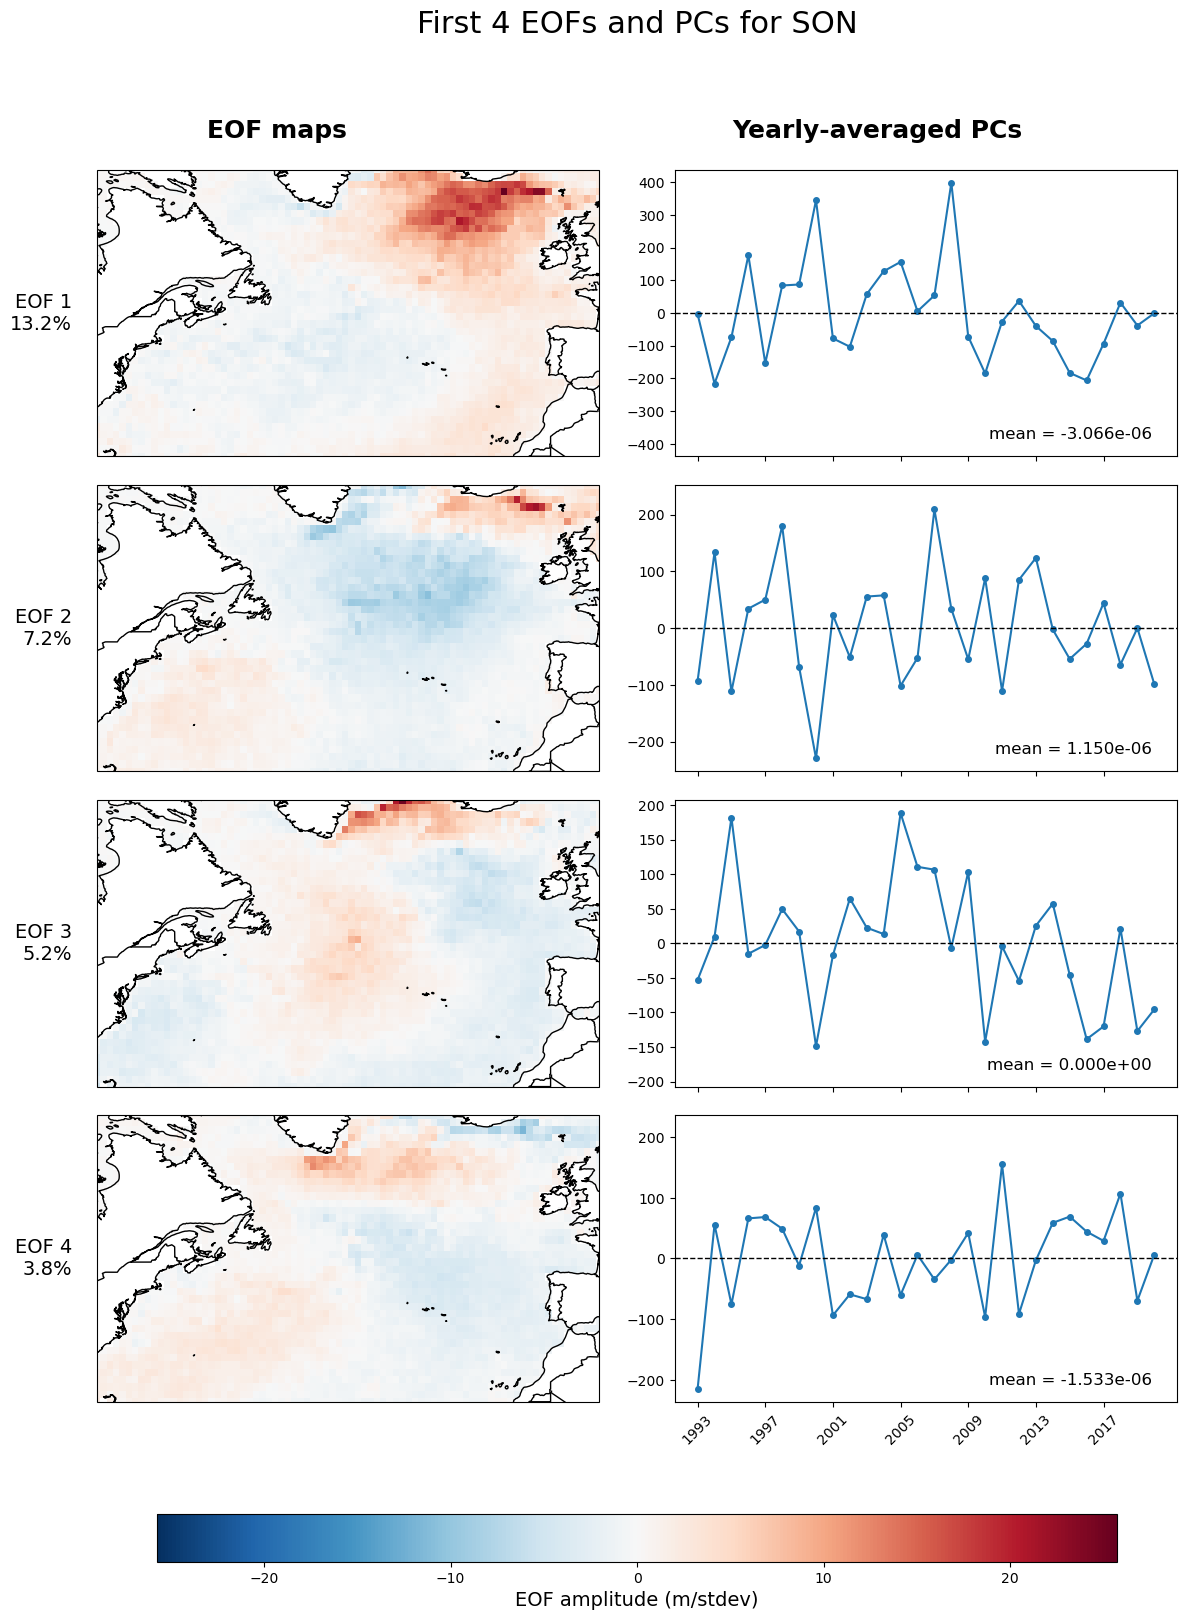

In [15]:
plot_seasonal_eofs_pcs(
    season_name=season,
    anom=eof_data[season]["anom"],
    eofs=eof_data[season]["eofs"],
    pcs=eof_data[season]["pcs"],
    explained_var=eof_data[season]["explained_var"],
    save_path=f"4PCs_for_{season}.png")

## CLUSTER ANALYSIS
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Clustering function

In [16]:
from sklearn.cluster import KMeans
import numpy as np

def cluster_analysis(dataset_name, pcs_std, eofs, n_clusters=4, max_iter=500, n_init=500, random_state=42):
    """
    Perform K-means clustering on a given dataset's PCs and reconstruct cluster spatial patterns.

    Parameters
    ----------
    dataset_name : str
        Name of the dataset (for printing progress), e.g., 'DJF', 'full', etc.
    pcs : ndarray (time, n_EOF)
        Principal components for each time step of the dataset.
    eofs : ndarray (n_EOF, lat, lon)
        EOF spatial patterns corresponding to the PCs.
    n_clusters : int, default=4
        Number of clusters for KMeans.
    max_iter : int, default=500
        Maximum iterations per KMeans run.
    n_init : int, default=500
        Number of random initializations for KMeans.
    random_state : int, default=42
        Random state for reproducibility.

    Returns
    -------
    labels : ndarray (time,)
        Cluster assignment for each time step.
    centroids : ndarray (n_clusters, n_EOF)
        PC values representing each cluster.
    cluster_patterns : ndarray (n_clusters, lat, lon)
        Reconstructed spatial patterns of each cluster.
    """
    
    print(f"\n--- Starting K-means clustering for {dataset_name} ---")
    print(f"Number of clusters: {n_clusters}")
    print(f"PCs shape (time, n_EOF): {pcs_std.shape}")

    # Perform KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, n_init=n_init, max_iter=max_iter, random_state=random_state)
    kmeans.fit(pcs_std)

    print(f"KMeans iterations run: {kmeans.n_iter_}")

    if kmeans.n_iter_ == max_iter:
        print("⚠️ WARNING: KMeans may NOT have converged (hit max_iter).")
    else:
        print("✅ KMeans converged before reaching max_iter.")

    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_

    print("Clustering completed!")
    print(f"Cluster counts (number of time steps per cluster): {np.bincount(labels)}")

    # Reconstruct cluster spatial patterns
    n_clusters_actual = centroids.shape[0]
    n_lat, n_lon = eofs.shape[1], eofs.shape[2]
    cluster_patterns = np.empty((n_clusters_actual, n_lat, n_lon))

    print("Reconstructing cluster spatial patterns from EOFs...")
    for i in range(n_clusters_actual):
        cluster_patterns[i] = np.tensordot(centroids[i], eofs, axes=([0],[0]))
    print("Cluster spatial patterns reconstructed.\n")

    return labels, centroids, cluster_patterns, dataset_name

#### Call cluster analysis function and store output

In [17]:
cluster_results = {}

for season, pcs_std, eofs in [
    ("DJF", DJF_pcs_std, DJF_eof),
    ("MAM", MAM_pcs_std, MAM_eof),
    ("JJA", JJA_pcs_std, JJA_eof),
    ("SON", SON_pcs_std, SON_eof),
    ("full", full_pcs_std, full_eof),]:
    
    labels, centroids, cluster_patterns, _ = cluster_analysis(dataset_name=season, pcs_std=pcs_std, eofs=eofs, n_clusters=4)

    cluster_results[season] = {"labels": labels, "centroids": centroids, "cluster_patterns": cluster_patterns}


--- Starting K-means clustering for DJF ---
Number of clusters: 4
PCs shape (time, n_EOF): (2520, 4)
KMeans iterations run: 30
✅ KMeans converged before reaching max_iter.
Clustering completed!
Cluster counts (number of time steps per cluster): [ 305 1140  132  943]
Reconstructing cluster spatial patterns from EOFs...
Cluster spatial patterns reconstructed.


--- Starting K-means clustering for MAM ---
Number of clusters: 4
PCs shape (time, n_EOF): (2576, 4)
KMeans iterations run: 9
✅ KMeans converged before reaching max_iter.
Clustering completed!
Cluster counts (number of time steps per cluster): [1577  317  601   81]
Reconstructing cluster spatial patterns from EOFs...
Cluster spatial patterns reconstructed.


--- Starting K-means clustering for JJA ---
Number of clusters: 4
PCs shape (time, n_EOF): (2576, 4)
KMeans iterations run: 17
✅ KMeans converged before reaching max_iter.
Clustering completed!
Cluster counts (number of time steps per cluster): [1055  426  481  614]
Reconstru

#### Map clustering results back onto calendar for all datasets
Composite preparation : A regime composite is the average spatial pattern for all times belonging to a specific regime.

In [18]:
import pandas as pd

# Dictionary to hold DataFrames for each season
cluster_calendar = {}

for season, data in cluster_results.items():
    
    # Pick the right time axis for this season
    if season == "full":
        regtime = full_anomalies.time.values
    else:
        regtime = eof_data[season]["anom"].time.values
    
    regtime = pd.to_datetime(regtime)
    time_strs = regtime.strftime('%Y-%m-%d').tolist()
    
    # Create DataFrame: rows = time, column = regime label
    cluster_calendar[season] = pd.DataFrame(
        data["labels"], index=time_strs, dtype='int', columns=["Regime"])
    
    
    # Example access

    # Access the DataFrame for a specific season
    #djf_df = cluster_calendar["DJF"]
    #print("First 5 rows of DJF cluster calendar:")
    #print(djf_df.head())
    
    # Access the regime label at a specific date
    #date_of_interest = "2000-01-15"
    #regime_label = djf_df.loc[date_of_interest, "Regime"]
    #print(f"\nRegime on {date_of_interest} for DJF: {regime_label}")
    
    # Loop through all seasons and show the first few rows
    # for season, df in cluster_calendar.items():
        #print(f"\nFirst 3 rows for {season}:")
        #print(df.head(3))

#### Compute regime composites for all datasets

In [19]:
# Dictionary to hold regime composites for each season
regime_composites = {}

for season, data in cluster_results.items():
    labels = data["labels"]
    
    # Pick the correct anomalies for this season
    if season == "full":
        anom_data = full_anomalies.values  # convert xarray to numpy
    else:
        anom_data = eof_data[season]["anom"].values
    
    ncluster = data["centroids"].shape[0]
    n_lat, n_lon = anom_data.shape[1], anom_data.shape[2]
    
    # Initialize array to hold composites
    regime_composite = np.full((ncluster, n_lat, n_lon), np.nan)
    
    # Compute mean map for each regime
    for r in range(ncluster):
        subset = np.where(labels == r)[0]  # indices of times in regime r
        if len(subset) > 0:
            regime_composite[r] = np.mean(anom_data[subset], axis=0)
    
    # Store in dictionary
    regime_composites[season] = regime_composite

# Example access
# regime_composites["DJF"][0] -> spatial map for DJF regime 0
# regime_composites["full"][2] -> spatial map for full dataset regime 2

#### Sort occupational frequency of all cluster

In [20]:
def sort_clusters_by_frequency(labels, centroids, cluster_patterns):
    """
    Relabel clusters so that the most frequent cluster is 0, next most frequent is 1, etc.

    Returns relabeled labels, reordered centroids & patterns, occurrence percentages, and regime names.
    """
    ncluster = centroids.shape[0]

    # Percentage occurrence of each cluster
    ratios = np.array([100 * np.sum(labels == i) / len(labels) for i in range(ncluster)])

    # Sort clusters by frequency (most → least frequent)
    idx_ratio_sort = np.argsort(ratios)[::-1]
    ratios_sorted = ratios[idx_ratio_sort]

    # Automatic regime names
    regnames = [f"Regime {i}" for i in range(ncluster)]

    # Reorder labels, centroids, and cluster patterns
    new_labels = np.empty_like(labels)
    new_centroids = np.empty_like(centroids)
    new_cluster_patterns = np.empty_like(cluster_patterns)

    for new_id, old_id in enumerate(idx_ratio_sort):
        new_labels[labels == old_id] = new_id
        new_centroids[new_id] = centroids[old_id]
        new_cluster_patterns[new_id] = cluster_patterns[old_id]

    return {
        "labels": new_labels.astype(int),
        "centroids": new_centroids,
        "cluster_patterns": new_cluster_patterns,
        "ratios_sorted": ratios_sorted,
        "regnames": regnames,
        "order": idx_ratio_sort}

## MAP REGIMES (fixed scale)
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Define map extent

In [21]:
def make_boundary_path(minlon,maxlon,minlat,maxlat,n=50):
    '''
    return a matplotlib Path whose points are a lon-lat box given by
    the input parameters
    '''
    boundary_path = []
    #North (E->W)
    edge = [np.linspace(minlon,maxlon,n), np.full(n,maxlat)]
    boundary_path += [[i,j] for i,j in zip(*edge)]
    #West (N->S)
    edge = [np.full(n,maxlon),np.linspace(maxlat,minlat,n)]
    boundary_path += [[i,j] for i,j in zip(*edge)]
    #South (W->E)
    edge = [np.linspace(maxlon,minlon,n), np.full(n,minlat)]
    boundary_path += [[i,j] for i,j in zip(*edge)]
    #East (S->N)
    edge = [np.full(n,minlon),np.linspace(minlat,maxlat,n)]
    boundary_path += [[i,j] for i,j in zip(*edge)]
    boundary_path = mpath.Path(boundary_path)
    return boundary_path

#### Mapping function (fixed scale)

In [22]:
def plot_mld_regimes(dataset_name, anom_data, regime_composite, regnames, ratios_sorted, save=True, dynamic_cbar=True, save_path=None):
    """
    Plot MLD regime composites for a given season with optional dynamic color scaling.
    """
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import numpy as np
    import matplotlib.colors as mcolors
    import matplotlib.cm as cm

    # -------------------------------
    # Determine colorbar limits
    # -------------------------------
    if dynamic_cbar:
        vmax = np.nanmax(np.abs(regime_composite))
    else:
        vmax = 5000  # fallback fixed max

    #vmax = 400

    clevs = np.linspace(-vmax, vmax, 21)
    cticks = np.linspace(-vmax, vmax, 9)
    
    base_cmap = plt.colormaps["RdBu_r"]
    cmap = base_cmap(np.linspace(-0.3, 1.3, 128))  # remove pale edges
    cmap = mcolors.ListedColormap(cmap)

    # -------------------------------
    # Lat/lon
    # -------------------------------
    lons = anom_data.longitude.values
    lats = anom_data.latitude.values
    extent = [np.min(lons), np.max(lons), np.min(lats), np.max(lats)]

    # -------------------------------
    # Figure and axes
    # -------------------------------
    fig, axs = plt.subplots(
        2, 2, figsize=(8, 5),
        subplot_kw={'projection': ccrs.LambertAzimuthalEqualArea(
            central_longitude=np.median(lons),
            central_latitude=np.median(lats))})
    plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.1, wspace=0.2, hspace=0.2)
    fig.suptitle(f"{dataset_name} MLD Regimes", fontsize=16, weight="bold")

    # -------------------------------
    # Plot regimes
    # -------------------------------
    for a, ax in enumerate(axs.reshape(-1)):
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        boundary = make_boundary_path(*extent)
        ax.set_boundary(boundary, transform=ccrs.PlateCarree())

        cf = ax.contourf(
            lons, lats, regime_composite[a],
            cmap=cmap, levels=clevs, extend="both",
            transform=ccrs.PlateCarree())

        ax.coastlines(color="k", resolution="50m", linewidth=0.5)
        ax.add_feature(cfeature.LAND, zorder=1, edgecolor="k")
        ax.set_title(f"{regnames[a]} [{ratios_sorted[a]:.1f}%]", weight="bold")

    # -------------------------------
    # Colorbar
    # -------------------------------
    cb_ax = fig.add_axes([0.112, 0, 0.8, 0.03])
    cbar = fig.colorbar(cf, cax=cb_ax, orientation="horizontal", ticks=cticks, extend="both", spacing="proportional")
    cbar.set_label("MLD anomaly (m)")

    # -------------------------------
    # Save / show
    # -------------------------------
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")
    plt.show()

#### Call regime mapping function (fixed scale)

Figure saved to 4regimes_for_full.png


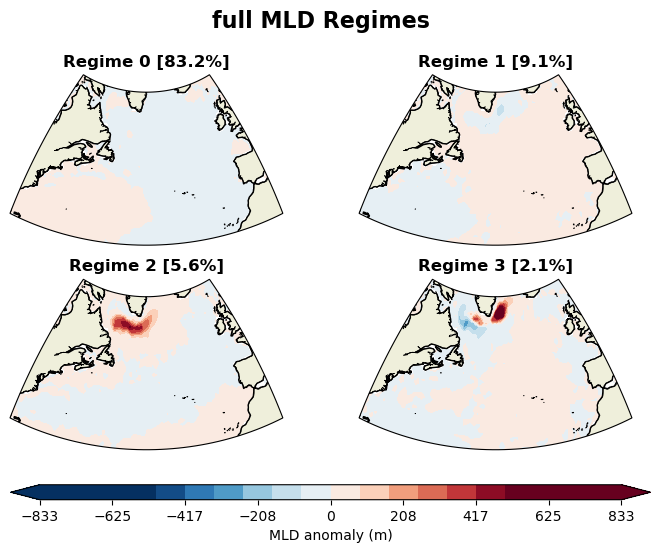

In [23]:
regime_data = {}

for season in cluster_results:
    # Choose the right anomaly DataArray
    if season == "full":
        anom_data = full_anomalies
    else:
        anom_data = eof_data[season]["anom"]
    
    # Sort clusters by frequency and relabel
    sorted_clusters = sort_clusters_by_frequency(
        cluster_results[season]["labels"],
        cluster_results[season]["centroids"],
        cluster_results[season]["cluster_patterns"])
    
    # Store everything for plotting
    regime_data[season] = {
        "anom": anom_data,
        "patterns": sorted_clusters["cluster_patterns"],
        "labels": sorted_clusters["labels"],
        "regnames": sorted_clusters["regnames"],
        "ratios": sorted_clusters["ratios_sorted"]}

# ----------------------------------
# Select season to plot
# ----------------------------------
season = "full"
plot_mld_regimes(
    dataset_name=season,
    anom_data=regime_data[season]["anom"],
    regime_composite=regime_data[season]["patterns"],
    regnames=regime_data[season]["regnames"],
    ratios_sorted=regime_data[season]["ratios"],
    save_path=f"4regimes_for_{season}.png")

## MAP REGIMES SCALED
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Mapping function (scaled)

In [24]:
def plot_mld_regimes_scaled(dataset_name, anom_data, regime_composite, regnames, ratios_sorted,
                     save=True, dynamic_cbar=True, save_path=None):

    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import numpy as np
    import matplotlib.colors as mcolors

    # -------------------------------
    # Colormap (same for all)
    # -------------------------------
    base_cmap = plt.colormaps["RdBu_r"]
    cmap = base_cmap(np.linspace(-0.1, 1, 128))  # remove pale edges
    cmap = mcolors.ListedColormap(cmap)

    # -------------------------------
    # Lat/lon
    # -------------------------------
    lons = anom_data.longitude.values
    lats = anom_data.latitude.values
    extent = [np.min(lons), np.max(lons), np.min(lats), np.max(lats)]

    # -------------------------------
    # Figure and axes
    # -------------------------------
    fig, axs = plt.subplots(
        2, 2, figsize=(9, 6),
        subplot_kw={'projection': ccrs.LambertAzimuthalEqualArea(
            central_longitude=np.median(lons),
            central_latitude=np.median(lats))}
    )

    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    fig.suptitle(f"{dataset_name} MLD Regimes", fontsize=16, weight="bold")

    # -------------------------------
    # Plot regimes (independent scaling)
    # -------------------------------
    for a, ax in enumerate(axs.reshape(-1)):

        data = regime_composite[a]

        # --- dynamic scaling per panel ---
        if dynamic_cbar:
            vmax = np.nanmax(np.abs(data))
        else:
            vmax = 5000

        clevs = np.linspace(-vmax, vmax, 21)
        cticks = np.linspace(-vmax, vmax, 5)

        ax.set_extent(extent, crs=ccrs.PlateCarree())
        boundary = make_boundary_path(*extent)
        ax.set_boundary(boundary, transform=ccrs.PlateCarree())

        cf = ax.contourf(
            lons, lats, data,
            cmap=cmap, levels=clevs, extend="both",
            transform=ccrs.PlateCarree()
        )

        ax.coastlines(color="k", resolution="50m", linewidth=0.5)
        ax.add_feature(cfeature.LAND, zorder=1, edgecolor="k")
        ax.set_title(f"{regnames[a]} [{ratios_sorted[a]:.1f}%]", weight="bold")

        # --- individual colorbar ---
        cbar = fig.colorbar(cf, ax=ax, orientation="horizontal",
                            pad=0.05, fraction=0.05, ticks=cticks)

    # -------------------------------
    # Save / show
    # -------------------------------
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    plt.show()

#### Call regime mapping function (scaled)

Figure saved to -5scaled_4regimes_for_JJA.png


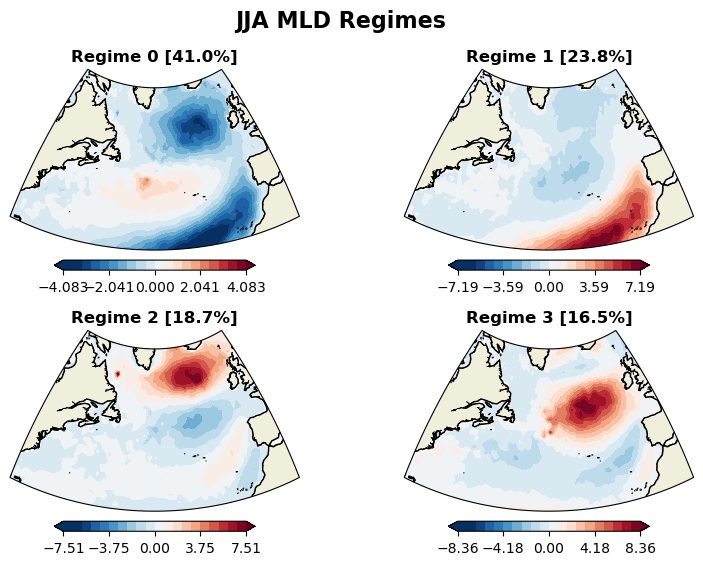

In [25]:
regime_data = {}

for season in cluster_results:
    # Choose the right anomaly DataArray
    if season == "full":
        anom_data = full_anomalies
    else:
        anom_data = eof_data[season]["anom"]
    
    # Sort clusters by frequency and relabel
    sorted_clusters = sort_clusters_by_frequency(
        cluster_results[season]["labels"],
        cluster_results[season]["centroids"],
        cluster_results[season]["cluster_patterns"])
    
    # Store everything for plotting
    regime_data[season] = {
        "anom": anom_data,
        "patterns": sorted_clusters["cluster_patterns"],
        "labels": sorted_clusters["labels"],
        "regnames": sorted_clusters["regnames"],
        "ratios": sorted_clusters["ratios_sorted"]}

# ----------------------------------
# Select season to plot
# ----------------------------------
season = "JJA"
plot_mld_regimes_scaled(
    dataset_name=season,
    anom_data=regime_data[season]["anom"],
    regime_composite=regime_data[season]["patterns"],
    regnames=regime_data[season]["regnames"],
    ratios_sorted=regime_data[season]["ratios"],
    save_path=f"-5scaled_4regimes_for_{season}.png")

## REGIME INDEXING
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Function to build regime calendar

In [31]:
def plot_regime_calendar(cluster_calendar, season="full", regnames=None, save=True, save_path=None):

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import matplotlib.patches as mpatches

    # ----------------------------------
    # Load data
    # ----------------------------------
    df = cluster_calendar[season].copy()
    df.index = pd.to_datetime(df.index)

    df["year"] = df.index.year
    df["doy"] = df.index.dayofyear
    df = df[df["doy"] <= 365]

    years = np.sort(df["year"].unique())
    n_years = len(years)
    n_days = 365

    # ----------------------------------
    # Create grid
    # ----------------------------------
    regime_grid = np.full((n_years, n_days), np.nan)

    for i, year in enumerate(years):
        year_data = df[df["year"] == year]
        doy = year_data["doy"].values - 1
        regime_grid[i, doy] = year_data["Regime"].values

    # ----------------------------------
    # Colormap
    # ----------------------------------
    n_regimes = int(np.nanmax(regime_grid)) + 1
    cmap = plt.get_cmap("tab10", n_regimes)
    norm = mcolors.BoundaryNorm(np.arange(-0.5, n_regimes + 0.5), cmap.N)

    # Default names if none provided
    if regnames is None:
        regnames = [f"Regime {i}" for i in range(n_regimes)]

    # ----------------------------------
    # Plot
    # ----------------------------------
    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(regime_grid, aspect="auto", cmap=cmap, norm=norm)

    # Y-axis
    ax.set_yticks(np.arange(n_years))
    ax.set_yticklabels(years)

    # X-axis months
    month_starts = pd.date_range("2001-01-01", "2001-12-31", freq="MS").dayofyear - 1
    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels)

    ax.set_xlabel("Month")
    ax.set_ylabel("Year")
    ax.set_title(f"Regime Calendar ({season})", fontsize=18)

    # ----------------------------------
    # DISCRETE LEGEND (key addition)
    # ----------------------------------
    legend_patches = [
        mpatches.Patch(color=cmap(i), label=regnames[i])
        for i in range(n_regimes)
    ]

    ax.legend(
        handles=legend_patches,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=n_regimes,
        frameon=False
    )

    # Optional: keep colorbar but make it cleaner
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_ticks(np.arange(n_regimes))
    cbar.set_ticklabels(regnames)
    cbar.set_label("Regime")

    ax.tick_params(axis='both', which='both', length=0)

    plt.tight_layout()

    if save and save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

#### Call regime calendar function

Saved to Regime Calendar


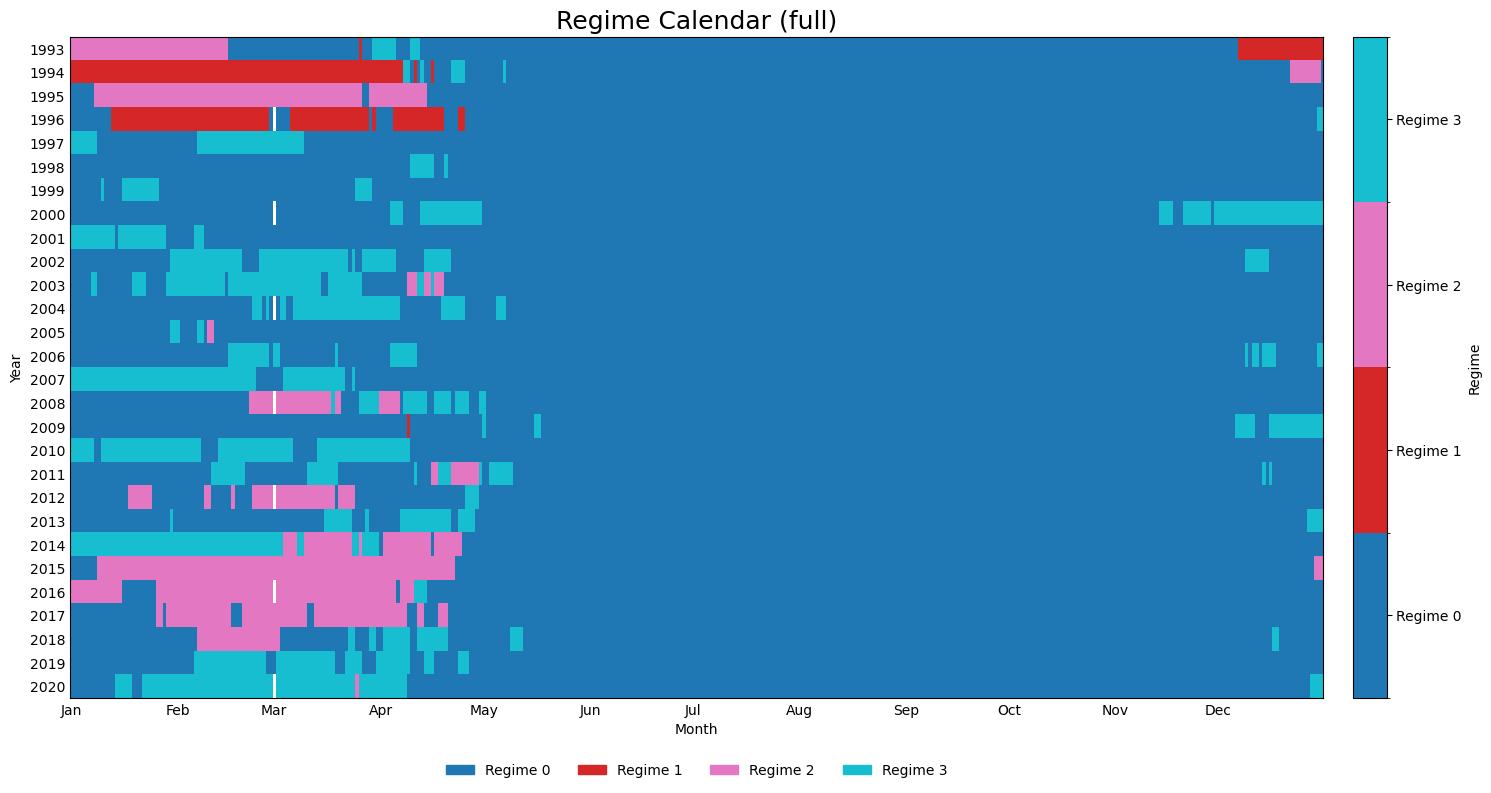

In [33]:
plot_regime_calendar(cluster_calendar, season="full", save=True, save_path="Regime Calendar")

#### Function to plot regime index over a season

In [34]:
def plot_IWR_period(
    anom_data,
    regime_composites,
    labels,
    start_date,
    end_date,
    regnames=None,
    save=False,
    save_path=None
):
    """
    Plot Intrinsic Weather Regime (IWR) index for a selected time period.

    Parameters
    ----------
    anom_data : xarray.DataArray (time, lat, lon)
        Your anomaly field (e.g. full_anomalies)
    regime_composites : ndarray (n_regimes, lat, lon)
        Regime composite maps (your regime_composites["full"])
    labels : ndarray (time,)
        Cluster labels (from clustering)
    start_date : str
        e.g. "2005-12-01"
    end_date : str
        e.g. "2006-02-28"
    regnames : list of str
        Optional regime names
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd

    # ----------------------------------
    # Extract time + subset
    # ----------------------------------
    time = pd.to_datetime(anom_data.time.values)

    mask = (time >= pd.to_datetime(start_date)) & (time <= pd.to_datetime(end_date))

    z_anoms = anom_data.values[mask]
    time_plot = time[mask]
    assigned_regimes = labels[mask]

    lats = anom_data.latitude.values
    ncluster = regime_composites.shape[0]

    # ----------------------------------
    # Area weighting (cos(lat))
    # ----------------------------------
    weights = np.cos(np.deg2rad(lats))
    weights_2D = weights[:, np.newaxis]

    # ----------------------------------
    # Projection onto regime composites
    # ----------------------------------
    projection = np.full((ncluster, len(z_anoms)), np.nan)

    for r in range(ncluster):
        pattern = regime_composites[r]

        for d in range(len(z_anoms)):
            field = z_anoms[d]

            projection[r, d] = np.nansum(
                (field * weights_2D) * pattern
            )

    # ----------------------------------
    # Normalize → IWR
    # ----------------------------------
    mean_proj = np.nanmean(projection, axis=1)
    std_proj = np.nanstd(projection, axis=1)

    IWR = (projection - mean_proj[:, np.newaxis]) / std_proj[:, np.newaxis]

    # ----------------------------------
    # Plot
    # ----------------------------------
    fig, ax = plt.subplots(figsize=(12, 6))

    colors = plt.get_cmap("tab10")(np.arange(ncluster))
    markers = ["o", "s", "^", "D", "v", "P", "*"]

    if regnames is None:
        regnames = [f"Regime {i}" for i in range(ncluster)]

    for r in range(ncluster):
        ax.plot(time_plot, IWR[r], color=colors[r], label=regnames[r])

        # Highlight strong events (>1σ)
        strong = np.ma.masked_less(IWR[r], 1)
        ax.plot(time_plot, strong, linestyle="None",
                marker=markers[r % len(markers)],
                color=colors[r])

    # ----------------------------------
    # Assigned regime markers (top row)
    # ----------------------------------
    # Determine dominant regime at each timestep
    dominant_regime = np.nanargmax(IWR, axis=0)
    
    for d in range(len(time_plot)):
        r = dominant_regime[d]  # strongest mode
        ax.scatter(time_plot[d], 4.3,  # fixed height above lines
                   color=colors[r],
                   marker=markers[r % len(markers)],
                   s=20)

    # ----------------------------------
    # Formatting
    # ----------------------------------
    ax.axhline(0, color='k', linewidth=1)
    ax.axhline(4, color='k', linewidth=1)

    ax.set_ylim(-4, 4.8)
    ax.set_ylabel("Regime Index (σ)")
    ax.set_title(f"Regime Index: {start_date} to {end_date}")

    ax.grid(linestyle=":")

    # Nice date ticks
    tick_mask = [t.day in [1, 15] for t in time_plot]
    tick_locs = time_plot[tick_mask]
    tick_labels = [t.strftime("%d %b %Y") for t in tick_locs]

    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=9)

    ax.legend(loc="lower center", ncol=ncluster)

    plt.tight_layout()

    # ----------------------------------
    # Save
    # ----------------------------------
    if save and save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

    return fig, IWR

#### Call regime season index function

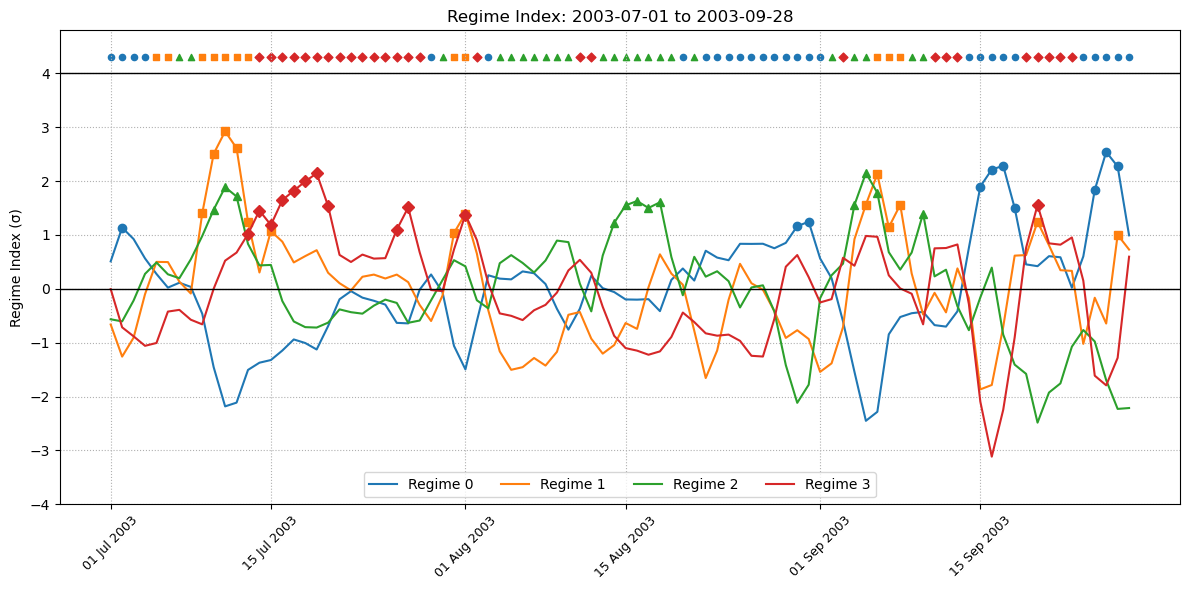

(<Figure size 1200x600 with 1 Axes>,
 array([[ 5.10078505e-01,  1.13745323e+00,  9.24647176e-01,
          5.64747241e-01,  2.76804828e-01,  2.24675673e-02,
          1.13303766e-01,  3.60532746e-02, -4.62228203e-01,
         -1.45560420e+00, -2.18249691e+00, -2.11305089e+00,
         -1.50560628e+00, -1.37156870e+00, -1.32209324e+00,
         -1.14583134e+00, -9.39733831e-01, -1.00589516e+00,
         -1.12603487e+00, -6.91802205e-01, -1.93680532e-01,
         -4.28814895e-02, -1.63636391e-01, -2.21747605e-01,
         -2.92825697e-01, -6.31801127e-01, -6.41480712e-01,
         -1.59814232e-02,  2.66483194e-01, -6.25515550e-02,
         -1.05856807e+00, -1.49586212e+00, -5.99428362e-01,
          2.51806760e-01,  1.89774793e-01,  1.75729329e-01,
          3.23522060e-01,  2.89299842e-01,  8.93318713e-02,
         -3.71872623e-01, -7.57916248e-01, -3.69547504e-01,
          2.42147557e-01,  1.22039967e-02, -5.97105288e-02,
         -1.96942669e-01, -2.00719106e-01, -1.91654548e-01,
   

In [36]:
plot_IWR_period(
    anom_data=full_anomalies,
    regime_composites=regime_composites["full"],
    labels=cluster_results["full"]["labels"],
    start_date="2003-07-01",
    end_date="2003-09-28"
)